# MADAD — NLM20 Medication Image Dataset EDA

**Purpose:** Evaluate the *Images of Pills Inside Medication Bottles* dataset (NLM20 folder) for a proof-of-concept **Visual Medication Verification** module in MADAD.

This notebook validates the provided Train/Validation/Test structure, builds an image manifest, attaches NDC-level medication metadata, evaluates class distribution and image quality, checks for exact duplicates and potential cross-split data leakage, and saves the resulting EDA outputs to Google Drive.

> **Important:** NDC-level medication metadata is used for **EDA, interpretation, and post-prediction lookup only**. It is not used as input to the image classification model because the metadata is associated with the target NDC class and could introduce target leakage.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Core imports
from pathlib import Path
from collections import Counter
import hashlib
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1. Paths and dataset structure

In [ ]:
DATA_ROOT = Path('/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20')
OUTPUT_DIR = Path('/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/nlm20_eda_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPLIT_DIRS = {
    'train': DATA_ROOT / 'train',
    'valid': DATA_ROOT / 'valid',
    'test': DATA_ROOT / 'test'
}

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

print('Dataset root :', DATA_ROOT)
print('Output folder:', OUTPUT_DIR)
print()

for split_name, split_dir in SPLIT_DIRS.items():
    print(f'{split_name:>5}: exists={split_dir.exists()}  path={split_dir}')

missing_splits = [name for name, path in SPLIT_DIRS.items() if not path.exists()]
if missing_splits:
    raise FileNotFoundError(f'Missing split folders: {missing_splits}')

print('\n✓ Train / Valid / Test folders were found.')

Dataset root : /content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20
Output folder: /content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/nlm20_eda_outputs

train: exists=True  path=/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20/train
valid: exists=True  path=/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20/valid
 test: exists=True  path=/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20/test

✓ Train / Valid / Test folders were found.


## 2. Published NDC-level metadata
The dataset contains 20 medication product classes identified by NDC. The table below is attached by NDC so that every image can be interpreted with its medication name and physical attributes.

In [ ]:
# Published 20-class metadata table associated with the dataset
metadata_rows = [
    ['00378-0208', 'Furosemide 20 mg oral tablet', 'Round', 'White', 'M2', 6, 602, 199, 200],
    ['00378-3855', 'Escitalopram 5 mg oral tablet', 'Round', 'White', 'M;EC5', 6, 129, 42, 42],
    ['00591-0461', 'Glipizide 10 mg oral tablet', 'Round', 'White', 'Watson;461', 10, 148, 48, 48],
    ['16729-0020', 'Pioglitazone 15 mg oral tablet', 'Round', 'White', 'P;15', 5, 258, 84, 85],
    ['16729-0168', 'Escitalopram 5 mg oral tablet', 'Round', 'White', '5', 5, 129, 42, 42],
    ['50111-0434', 'Trazodone hydrochloride 100 mg oral tablet', 'Round', 'White', 'PLIVA;434', 11, 601, 199, 200],
    ['53489-0156', 'Allopurinol 100 mg oral tablet', 'Round', 'White', 'MP;71', 10, 600, 200, 200],
    ['53746-0544', 'Primidone 50 mg oral tablet', 'Round', 'White', 'AN;44', 6, 97, 31, 32],
    ['57664-0377', 'Tramadol hydrochloride 50 mg oral tablet', 'Capsule', 'White', '377', 13, 601, 199, 200],
    ['62037-0831', 'Metoprolol succinate 50 mg extended-release tablet', 'Round', 'White', '831', 9, 600, 200, 200],
    ['62037-0832', 'Metoprolol succinate 100 mg extended-release tablet', 'Round', 'White', '832', 10, 601, 200, 200],
    ['64380-0803', 'Ranitidine 150 mg oral tablet (Strides Pharma)', 'Round', 'Brown', 'S;429', 10, 548, 181, 182],
    ['65162-0253', 'Ranitidine 150 mg oral tablet (Amneal Pharmaceuticals)', 'Round', 'Orange', 'IP;253', 9, 557, 184, 185],
    ['67253-0901', 'Alprazolam 0.5 mg oral tablet', 'Oval', 'Yellow', 'S901', 9, 497, 164, 165],
    ['68382-0008', 'Lamotrigine 100 mg oral tablet', 'Round', 'White', 'ZC;80', 10, 423, 139, 140],
    ['68382-0227', 'Amiodarone hydrochloride 200 mg oral tablet', 'Round', 'White', 'ZE;65', 10, 120, 39, 39],
    ['69097-0127', 'Amlodipine 5 mg oral tablet', 'Round', 'White', '127;C', 8, 600, 200, 200],
    ['69097-0128', 'Amlodipine 10 mg oral tablet', 'Round', 'White', '128;C', 8, 600, 200, 200],
    ['69315-0904', 'Lorazepam 0.5 mg oral tablet', 'Round', 'White', 'EP;904', 5, 357, 118, 118],
    ['69315-0905', 'Lorazepam 1 mg oral tablet', 'Round', 'White', 'EP;905;1', 7, 325, 107, 108],
]

meta = pd.DataFrame(
    metadata_rows,
    columns=[
        'ndc', 'drug_name', 'shape', 'color', 'imprint', 'size_mm',
        'expected_train', 'expected_valid', 'expected_test'
    ]
)

meta['expected_total'] = meta[['expected_train', 'expected_valid', 'expected_test']].sum(axis=1)

print('Metadata classes:', meta['ndc'].nunique())
print('Expected total images:', int(meta['expected_total'].sum()))
display(meta)

Metadata classes: 20
Expected total images: 13955


,ndc,drug_name,shape,color,imprint,size_mm,expected_train,expected_valid,expected_test,expected_total
0,00378-0208,Furosemide 20 mg oral tablet,Round,White,M2,6,602,199,200,1001
1,00378-3855,Escitalopram 5 mg oral tablet,Round,White,M;EC5,6,129,42,42,213
2,00591-0461,Glipizide 10 mg oral tablet,Round,White,Watson;461,10,148,48,48,244
3,16729-0020,Pioglitazone 15 mg oral tablet,Round,White,P;15,5,258,84,85,427
4,16729-0168,Escitalopram 5 mg oral tablet,Round,White,5,5,129,42,42,213
5,50111-0434,Trazodone hydrochloride 100 mg oral tablet,Round,White,PLIVA;434,11,601,199,200,1000
6,53489-0156,Allopurinol 100 mg oral tablet,Round,White,MP;71,10,600,200,200,1000
7,53746-0544,Primidone 50 mg oral tablet,Round,White,AN;44,6,97,31,32,160
8,57664-0377,Tramadol hydrochloride 50 mg oral tablet,Capsule,White,377,13,601,199,200,1000
9,62037-0831,Metoprolol succinate 50 mg extended-release ta...,Round,White,831,9,600,200,200,1000


## 3. Build the image manifest

In [ ]:
records = []

for split_name, split_dir in SPLIT_DIRS.items():
    class_dirs = sorted([p for p in split_dir.iterdir() if p.is_dir()])

    for class_dir in class_dirs:
        ndc = class_dir.name

        for image_path in sorted(class_dir.iterdir()):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    'image_id': image_path.stem,
                    'filename': image_path.name,
                    'image_path': str(image_path),
                    'split': split_name,
                    'ndc': ndc
                })

manifest = pd.DataFrame(records)
manifest = manifest.merge(meta, on='ndc', how='left', validate='many_to_one')

print('Total images:', len(manifest))
print('Unique NDC classes:', manifest['ndc'].nunique())
print('Missing metadata rows:', int(manifest['drug_name'].isna().sum()))
print('\nImages by split:')
display(manifest.groupby('split').size().rename('images').to_frame())

assert manifest['ndc'].nunique() == 20, 'Expected 20 NDC classes.'
assert len(manifest) == 13955, f'Expected 13,955 images, found {len(manifest):,}.'
assert manifest['drug_name'].notna().all(), 'Some NDC folders did not match the metadata table.'

print('✓ Manifest matches the published total: 13,955 images and 20 NDC classes.')

Total images: 13955
Unique NDC classes: 20
Missing metadata rows: 0

Images by split:


,images
split,
test,2786
train,8393
valid,2776


✓ Manifest matches the published total: 13,955 images and 20 NDC classes.


## 4. Compare observed counts with published counts

In [ ]:
observed = (
    manifest.groupby(['ndc', 'split'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={'train': 'observed_train', 'valid': 'observed_valid', 'test': 'observed_test'})
)

class_summary = meta.merge(observed, on='ndc', how='left')

for split_name in ['train', 'valid', 'test']:
    class_summary[f'diff_{split_name}'] = (
        class_summary[f'observed_{split_name}'] - class_summary[f'expected_{split_name}']
    )

class_summary['observed_total'] = class_summary[[
    'observed_train', 'observed_valid', 'observed_test'
]].sum(axis=1)
class_summary['diff_total'] = class_summary['observed_total'] - class_summary['expected_total']

comparison_cols = [
    'ndc', 'drug_name',
    'expected_train', 'observed_train', 'diff_train',
    'expected_valid', 'observed_valid', 'diff_valid',
    'expected_test', 'observed_test', 'diff_test',
    'expected_total', 'observed_total', 'diff_total'
]

display(class_summary[comparison_cols])

all_match = (class_summary[['diff_train', 'diff_valid', 'diff_test']] == 0).all().all()
print('All observed split counts match the published counts:', all_match)

,ndc,drug_name,expected_train,observed_train,diff_train,expected_valid,observed_valid,diff_valid,expected_test,observed_test,diff_test,expected_total,observed_total,diff_total
0,00378-0208,Furosemide 20 mg oral tablet,602,602,0,199,199,0,200,200,0,1001,1001,0
1,00378-3855,Escitalopram 5 mg oral tablet,129,129,0,42,42,0,42,42,0,213,213,0
2,00591-0461,Glipizide 10 mg oral tablet,148,148,0,48,48,0,48,48,0,244,244,0
3,16729-0020,Pioglitazone 15 mg oral tablet,258,258,0,84,84,0,85,85,0,427,427,0
4,16729-0168,Escitalopram 5 mg oral tablet,129,129,0,42,42,0,42,42,0,213,213,0
5,50111-0434,Trazodone hydrochloride 100 mg oral tablet,601,601,0,199,199,0,200,200,0,1000,1000,0
6,53489-0156,Allopurinol 100 mg oral tablet,600,600,0,200,200,0,200,200,0,1000,1000,0
7,53746-0544,Primidone 50 mg oral tablet,97,97,0,31,31,0,32,32,0,160,160,0
8,57664-0377,Tramadol hydrochloride 50 mg oral tablet,601,601,0,199,199,0,200,200,0,1000,1000,0
9,62037-0831,Metoprolol succinate 50 mg extended-release ta...,600,600,0,200,200,0,200,200,0,1000,1000,0


All observed split counts match the published counts: True


## 5. Basic integrity checks

In [ ]:
split_class_sets = {
    split_name: set(manifest.loc[manifest['split'] == split_name, 'ndc'].unique())
    for split_name in ['train', 'valid', 'test']
}

for split_name, classes in split_class_sets.items():
    print(f'{split_name}: {len(classes)} classes')

print('Same 20 classes in all splits:',
      split_class_sets['train'] == split_class_sets['valid'] == split_class_sets['test'])

print('\nDuplicate filenames across the full dataset:', int(manifest['filename'].duplicated().sum()))
print('Duplicate image IDs across the full dataset:', int(manifest['image_id'].duplicated().sum()))

filename_duplicates = manifest[manifest['filename'].duplicated(keep=False)].sort_values('filename')
image_id_duplicates = manifest[manifest['image_id'].duplicated(keep=False)].sort_values('image_id')

if len(filename_duplicates):
    display(filename_duplicates.head(20))

train: 20 classes
valid: 20 classes
test: 20 classes
Same 20 classes in all splits: True

Duplicate filenames across the full dataset: 0
Duplicate image IDs across the full dataset: 0


## 6. Class distribution

In [ ]:
distribution = (
    manifest.groupby(['ndc', 'split'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['train', 'valid', 'test'])
)
distribution['total'] = distribution.sum(axis=1)
distribution = distribution.sort_values('total', ascending=False)

display(distribution)

print('Largest class:', distribution['total'].idxmax(), int(distribution['total'].max()))
print('Smallest class:', distribution['total'].idxmin(), int(distribution['total'].min()))
print('Imbalance ratio (largest / smallest):', round(distribution['total'].max() / distribution['total'].min(), 2))

split,train,valid,test,total
ndc,,,,
00378-0208,602,199,200,1001
62037-0832,601,200,200,1001
50111-0434,601,199,200,1000
57664-0377,601,199,200,1000
62037-0831,600,200,200,1000
69097-0128,600,200,200,1000
69097-0127,600,200,200,1000
53489-0156,600,200,200,1000
65162-0253,557,184,185,926


Largest class: 00378-0208 1001
Smallest class: 53746-0544 160
Imbalance ratio (largest / smallest): 6.26


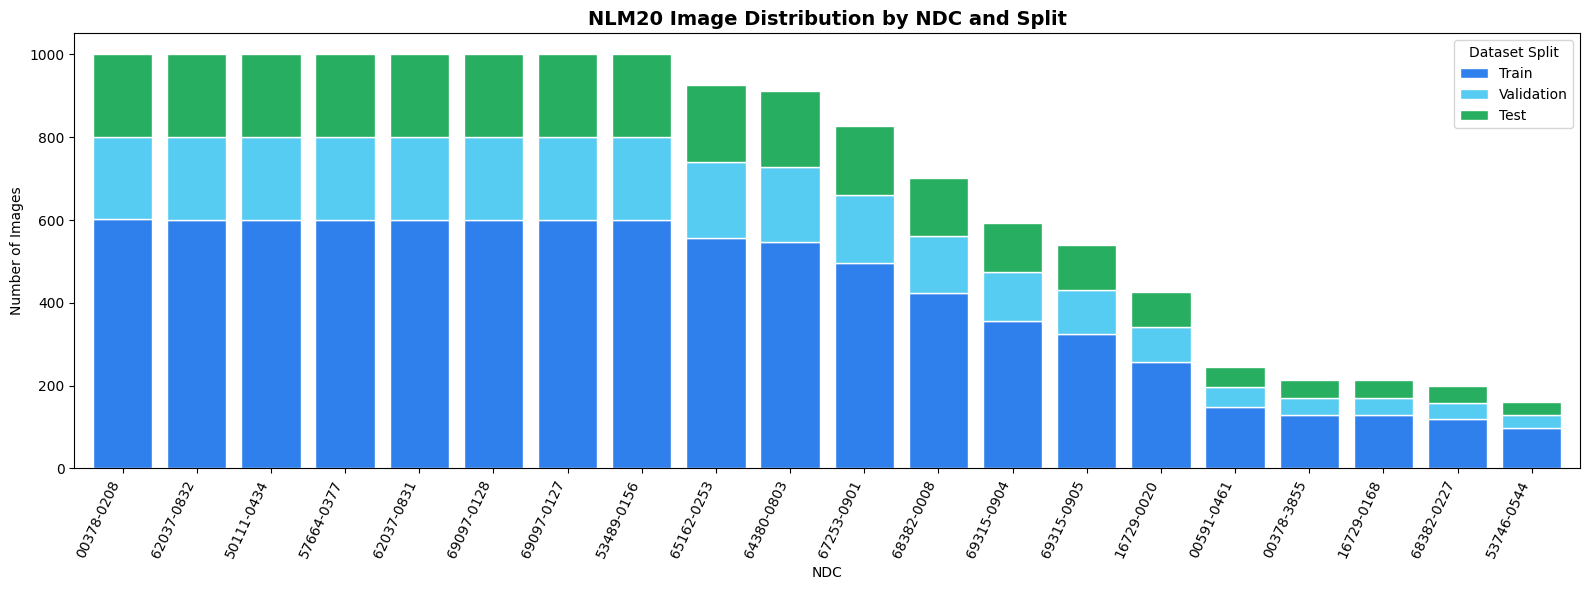

In [ ]:
plot_df = distribution[['train', 'valid', 'test']].copy()

medical_colors = [
    '#2F80ED',  # Medical Blue
    '#56CCF2',  # Light Clinical Blue
    '#27AE60'   # Healthcare Green
]

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    color=medical_colors,
    edgecolor='white',
    width=0.8
)

ax.set_title(
    'NLM20 Image Distribution by NDC and Split',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('NDC')
ax.set_ylabel('Number of Images')

plt.xticks(
    rotation=65,
    ha='right'
)

plt.legend(
    title='Dataset Split',
    labels=['Train', 'Validation', 'Test']
)

plt.tight_layout()
plt.show()

## 7. Image readability, dimensions, and channels
This scans all images once. On Google Drive it may take a few minutes.

In [ ]:
image_checks = []

for row in tqdm(manifest[['image_path']].itertuples(index=False), total=len(manifest), desc='Checking images'):
    image_path = row.image_path

    try:
        with Image.open(image_path) as img:
            img.verify()

        with Image.open(image_path) as img:
            width, height = img.size
            mode = img.mode

        image_checks.append({
            'image_path': image_path,
            'readable': True,
            'width': width,
            'height': height,
            'mode': mode,
            'error': None
        })

    except Exception as e:
        image_checks.append({
            'image_path': image_path,
            'readable': False,
            'width': np.nan,
            'height': np.nan,
            'mode': None,
            'error': str(e)
        })

image_quality = pd.DataFrame(image_checks)
manifest = manifest.merge(image_quality, on='image_path', how='left', validate='one_to_one')

print('Readable images:', int(manifest['readable'].sum()))
print('Unreadable/corrupted images:', int((~manifest['readable']).sum()))

print('\nImage modes:')
display(manifest['mode'].value_counts(dropna=False).rename('count').to_frame())

print('\nMost common image dimensions:')
display(
    manifest.groupby(['width', 'height'])
    .size()
    .sort_values(ascending=False)
    .head(20)
    .rename('count')
    .to_frame()
)

corrupted = manifest.loc[~manifest['readable'], ['image_path', 'split', 'ndc', 'error']]
if len(corrupted):
    display(corrupted)

Checking images:   0%|          | 0/13955 [00:00<?, ?it/s]

Readable images: 13955
Unreadable/corrupted images: 0

Image modes:


,count
mode,
RGB,13955



Most common image dimensions:


,,count
width,height,
1284,960,13955


## 8. Exact duplicate and cross-split leakage check
An MD5 hash is calculated for each image. Exact duplicate content across Train/Validation/Test is especially important because it can inflate evaluation performance.

In [ ]:
def md5_file(path, chunk_size=1024 * 1024):
    hasher = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            hasher.update(chunk)
    return hasher.hexdigest()

hashes = []

for image_path in tqdm(manifest['image_path'], total=len(manifest), desc='Hashing images'):
    try:
        hashes.append(md5_file(image_path))
    except Exception:
        hashes.append(None)

manifest['md5'] = hashes

dup_mask = manifest['md5'].notna() & manifest['md5'].duplicated(keep=False)
duplicate_rows = manifest.loc[dup_mask].copy()

if len(duplicate_rows):
    duplicate_group_summary = (
        duplicate_rows.groupby('md5')
        .agg(
            images=('image_path', 'size'),
            splits=('split', lambda s: '|'.join(sorted(set(s)))),
            n_splits=('split', 'nunique'),
            ndcs=('ndc', lambda s: '|'.join(sorted(set(s)))),
            n_ndcs=('ndc', 'nunique')
        )
        .reset_index()
        .sort_values(['n_splits', 'images'], ascending=[False, False])
    )
else:
    duplicate_group_summary = pd.DataFrame(columns=['md5', 'images', 'splits', 'n_splits', 'ndcs', 'n_ndcs'])

cross_split_groups = duplicate_group_summary[duplicate_group_summary['n_splits'] > 1].copy()
conflicting_label_groups = duplicate_group_summary[duplicate_group_summary['n_ndcs'] > 1].copy()

print('Exact duplicate groups:', len(duplicate_group_summary))
print('Images involved in exact duplicate groups:', len(duplicate_rows))
print('Cross-split duplicate groups:', len(cross_split_groups))
print('Duplicate groups with conflicting NDC labels:', len(conflicting_label_groups))

if len(cross_split_groups):
    print('\n⚠ Cross-split exact duplicates detected:')
    display(cross_split_groups.head(30))
else:
    print('\n✓ No exact duplicate image content was found across different splits.')

if len(conflicting_label_groups):
    print('\n⚠ Exact duplicates with different NDC labels detected:')
    display(conflicting_label_groups.head(30))

Hashing images:   0%|          | 0/13955 [00:00<?, ?it/s]

Exact duplicate groups: 0
Images involved in exact duplicate groups: 0
Cross-split duplicate groups: 0
Duplicate groups with conflicting NDC labels: 0

✓ No exact duplicate image content was found across different splits.


## 9. Medication metadata overview

In [ ]:
print('Shape distribution across the 20 NDC classes:')
display(meta['shape'].value_counts().rename('classes').to_frame())

print('Color distribution across the 20 NDC classes:')
display(meta['color'].value_counts().rename('classes').to_frame())

print('Unique imprints:', meta['imprint'].nunique(), 'out of', len(meta), 'classes')
print('Unique drug names:', meta['drug_name'].nunique(), 'out of', len(meta), 'classes')

print('\nObservation: many classes share similar visual properties such as round shape and white color,')
print('so the task is not trivial and fine details such as imprint, size, and pill appearance may be important.')

Shape distribution across the 20 NDC classes:


,classes
shape,
Round,18
Capsule,1
Oval,1


Color distribution across the 20 NDC classes:


,classes
color,
White,17
Brown,1
Orange,1
Yellow,1


Unique imprints: 20 out of 20 classes
Unique drug names: 19 out of 20 classes

Observation: many classes share similar visual properties such as round shape and white color,
so the task is not trivial and fine details such as imprint, size, and pill appearance may be important.


## 10. One sample image from each NDC class

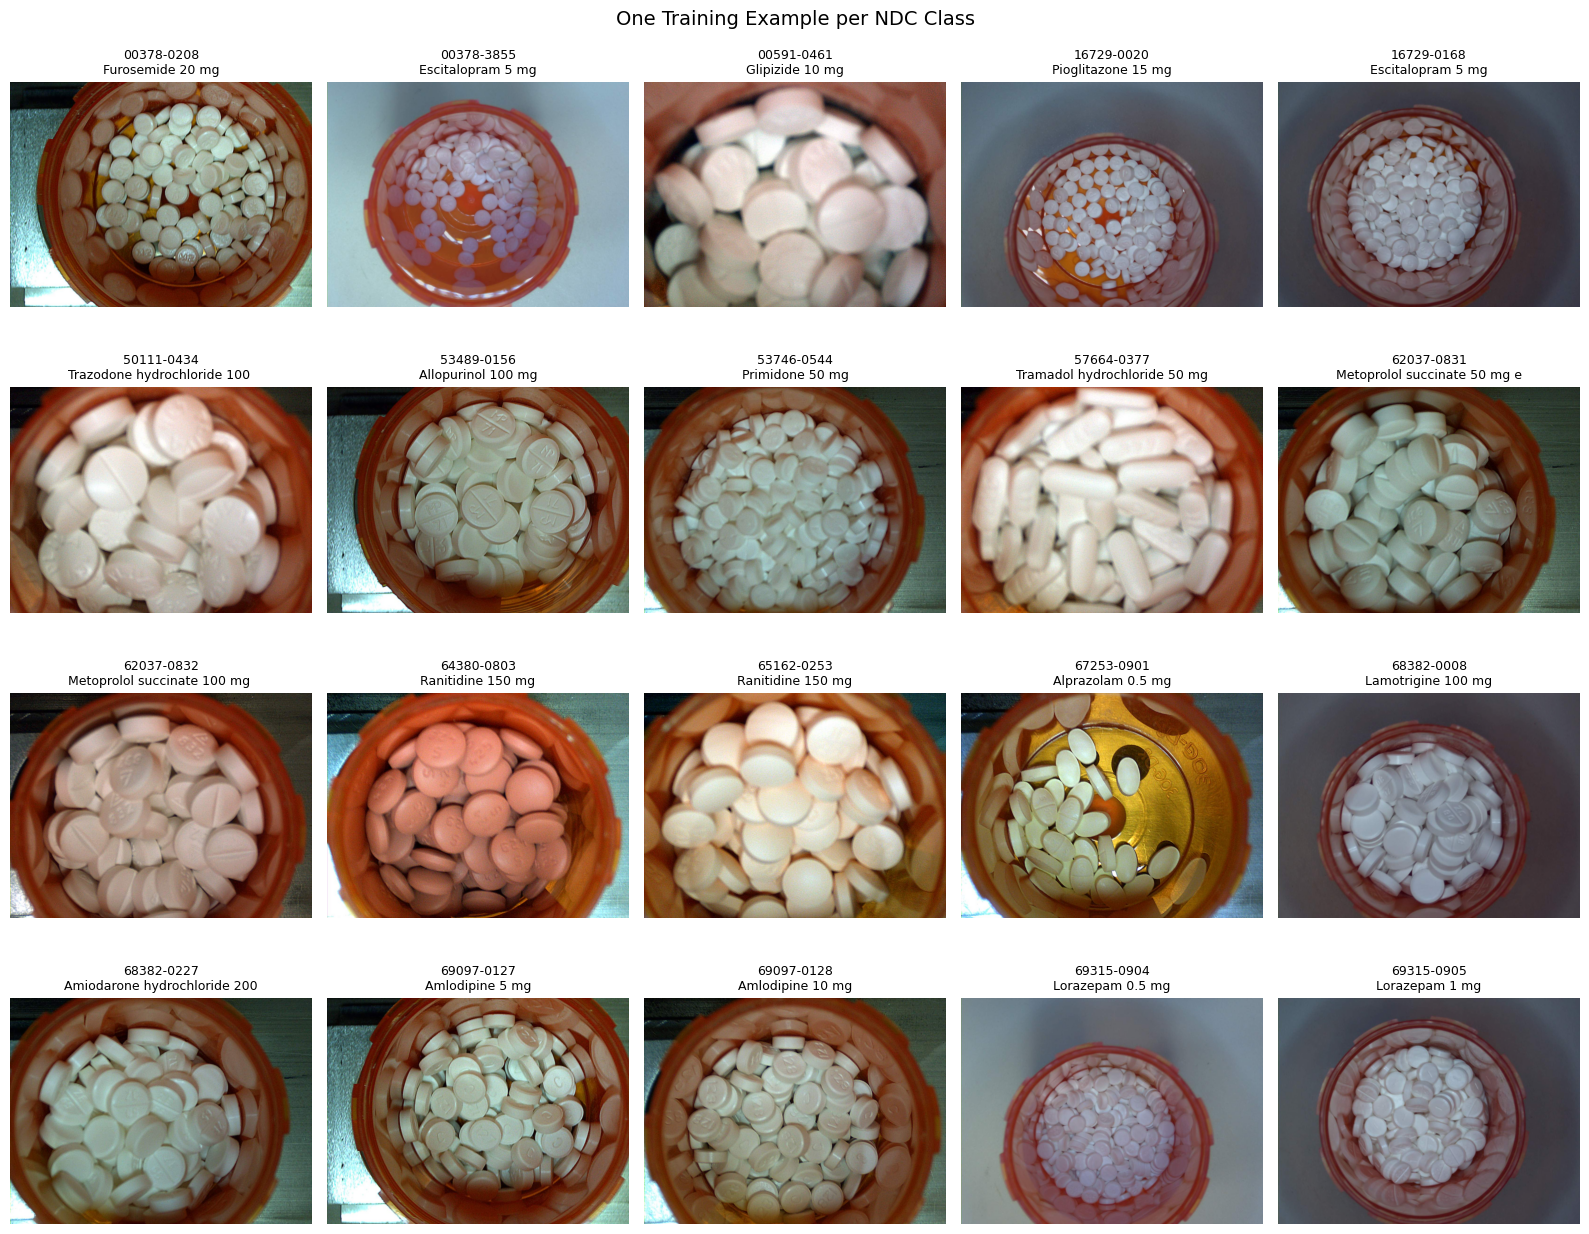

In [ ]:
train_manifest = manifest[manifest['split'] == 'train'].copy()
sample_rows = (
    train_manifest.groupby('ndc', group_keys=False)
    .sample(n=1, random_state=RANDOM_STATE)
    .sort_values('ndc')
    .reset_index(drop=True)
)

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    with Image.open(row['image_path']) as img:
        ax.imshow(img.convert('RGB'))
    ax.set_title(f"{row['ndc']}\n{row['drug_name'].split(' oral ')[0][:28]}", fontsize=9)
    ax.axis('off')

plt.suptitle('One Training Example per NDC Class', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Save EDA outputs

In [ ]:
# Detailed duplicate report at image level
if len(duplicate_rows):
    duplicate_report = duplicate_rows.merge(
        duplicate_group_summary[['md5', 'images', 'splits', 'n_splits', 'ndcs', 'n_ndcs']],
        on='md5',
        how='left',
        validate='many_to_one'
    ).sort_values(['n_splits', 'md5', 'split'], ascending=[False, True, True])
else:
    duplicate_report = pd.DataFrame()

eda_summary = pd.DataFrame({
    'metric': [
        'total_images',
        'ndc_classes',
        'train_images',
        'valid_images',
        'test_images',
        'readable_images',
        'corrupted_images',
        'exact_duplicate_groups',
        'images_in_duplicate_groups',
        'cross_split_duplicate_groups',
        'conflicting_ndc_duplicate_groups',
        'smallest_class_size',
        'largest_class_size',
        'class_imbalance_ratio'
    ],
    'value': [
        len(manifest),
        manifest['ndc'].nunique(),
        int((manifest['split'] == 'train').sum()),
        int((manifest['split'] == 'valid').sum()),
        int((manifest['split'] == 'test').sum()),
        int(manifest['readable'].sum()),
        int((~manifest['readable']).sum()),
        len(duplicate_group_summary),
        len(duplicate_rows),
        len(cross_split_groups),
        len(conflicting_label_groups),
        int(distribution['total'].min()),
        int(distribution['total'].max()),
        round(float(distribution['total'].max() / distribution['total'].min()), 4)
    ]
})

manifest.to_csv(OUTPUT_DIR / 'nlm20_image_manifest.csv', index=False)
class_summary.to_csv(OUTPUT_DIR / 'nlm20_class_summary.csv', index=False)
meta.to_csv(OUTPUT_DIR / 'nlm20_metadata_20_ndc.csv', index=False)
duplicate_report.to_csv(OUTPUT_DIR / 'nlm20_duplicate_report.csv', index=False)
duplicate_group_summary.to_csv(OUTPUT_DIR / 'nlm20_duplicate_group_summary.csv', index=False)
eda_summary.to_csv(OUTPUT_DIR / 'nlm20_eda_summary.csv', index=False)

print('Saved outputs to:', OUTPUT_DIR)
for file in sorted(OUTPUT_DIR.glob('nlm20_*.csv')):
    print(' -', file.name)

display(eda_summary)

Saved outputs to: /content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/nlm20_eda_outputs
 - nlm20_class_summary.csv
 - nlm20_duplicate_group_summary.csv
 - nlm20_duplicate_report.csv
 - nlm20_eda_summary.csv
 - nlm20_image_manifest.csv
 - nlm20_metadata_20_ndc.csv


,metric,value
0,total_images,13955.0000
1,ndc_classes,20.0000
2,train_images,8393.0000
3,valid_images,2776.0000
4,test_images,2786.0000
5,readable_images,13955.0000
6,corrupted_images,0.0000
7,exact_duplicate_groups,0.0000
8,images_in_duplicate_groups,0.0000
9,cross_split_duplicate_groups,0.0000


## 12. Automated feasibility conclusion

In [ ]:
issues = []

if len(manifest) != 13955:
    issues.append(f'Image count differs from the published 13,955 images ({len(manifest):,} found).')

if manifest['ndc'].nunique() != 20:
    issues.append(f'Expected 20 NDC classes but found {manifest["ndc"].nunique()}.')

if (~manifest['readable']).sum() > 0:
    issues.append(f'{int((~manifest["readable"]).sum())} unreadable/corrupted images were detected.')

if len(cross_split_groups) > 0:
    issues.append(f'{len(cross_split_groups)} exact-duplicate groups occur across different splits and should be handled before final evaluation.')

if len(conflicting_label_groups) > 0:
    issues.append(f'{len(conflicting_label_groups)} exact-duplicate groups contain conflicting NDC labels and require inspection.')

print('NLM20 EDA — Final Feasibility Decision')
print('=' * 45)
print(f'Total images: {len(manifest):,}')
print(f'NDC classes: {manifest["ndc"].nunique()}')
print(f'Train / Valid / Test: {(manifest["split"] == "train").sum():,} / {(manifest["split"] == "valid").sum():,} / {(manifest["split"] == "test").sum():,}')
print(f'Class-size range: {int(distribution["total"].min())} to {int(distribution["total"].max())} images')
print(f'Imbalance ratio: {distribution["total"].max() / distribution["total"].min():.2f}x')
print(f'Cross-split exact duplicate groups: {len(cross_split_groups)}')
print()

if issues:
    print('Feasibility: PROMISING, WITH DATA-QUALITY ITEMS TO REVIEW')
    print('The dataset is still suitable for a proof-of-concept 20-class medication product recognition module,')
    print('but the following items should be addressed before final modeling/evaluation:')
    for issue in issues:
        print(' -', issue)
else:
    print('Feasibility: SUITABLE FOR MODELING')
    print('The dataset is suitable for a proof-of-concept 20-class medication product recognition module.')
    print('The official Train/Validation/Test split can be preserved for the first baseline model.')

NLM20 EDA — Final Feasibility Decision
Total images: 13,955
NDC classes: 20
Train / Valid / Test: 8,393 / 2,776 / 2,786
Class-size range: 160 to 1001 images
Imbalance ratio: 6.26x
Cross-split exact duplicate groups: 0

Feasibility: SUITABLE FOR MODELING
The dataset is suitable for a proof-of-concept 20-class medication product recognition module.
The official Train/Validation/Test split can be preserved for the first baseline model.
